In [112]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import sys
    
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
result_path = PROJECT_ROOT / "experiment_new" / "results"
plots_path = PROJECT_ROOT / "experiment_new" / "plots"

palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F",   # teal
    "scr": "#6D597A" # gray
}
p_list = ["p_05", "p_1", "p_5"]
a_list = ["a_1", "a_5", "a_10"]
algorithms = ["cup", "cas", "cor"]

sns.set_theme(context="notebook", style="whitegrid")

In [19]:
JSON_COLUMNS = ["n", "m", "k", "T_old", "T_up", "T_scr", "T_delta", "q_lens", "q_len_average", 
                "W", "W_scr", "v_changed", "changed_edges", "S", "colorings_up"]

def load_json(x):
    try:
        return json.loads(x)
    except:
        return x
    
def unpack_file(f_name, update_function):
    """Load the results from a CSV file into a DataFrame, 
    converting JSON strings to Python objects."""
    
    path = result_path /  f"result_{f_name}_{update_function}.csv"
    df = pd.read_csv(
        path,
        converters={col: load_json for col in JSON_COLUMNS}
    )
    df = df.sort_values("n")
    return df

def df_categorical(result_dict, col, col_scr=None):
    """Convert the results from a dictionary to a long-format DataFrame for plotting."""
    
    n_list = list(result_dict["cup"]["n"])
    if col_scr is not None:
        df_wide = pd.DataFrame({
            "graph_id": range(len(n_list)),
            "n": n_list,
            "cup": list(result_dict["cup"][col]),
            "cas": list(result_dict["cas"][col]),
            "cor": list(result_dict["cor"][col]),
            "scr": list(result_dict["cup"][col_scr])
        })
    else:
        df_wide = pd.DataFrame({
            "graph_id": range(len(n_list)),
            "n": n_list,
            "cup": list(result_dict["cup"][col]),
            "cas": list(result_dict["cas"][col]),
            "cor": list(result_dict["cor"][col])
        })

    df_long = df_wide.melt(
        id_vars=["graph_id", "n"],
        var_name="algorithm",
        value_name=col
    )
    
    return df_long

### Plot results for trees
1. W
2. Delta C - the vertices that changed their color relative to the original coloring
3. Closer look at T_delta 

In [ ]:
results_trees = {up_func: unpack_file("trees", up_func) for up_func in algorithms}

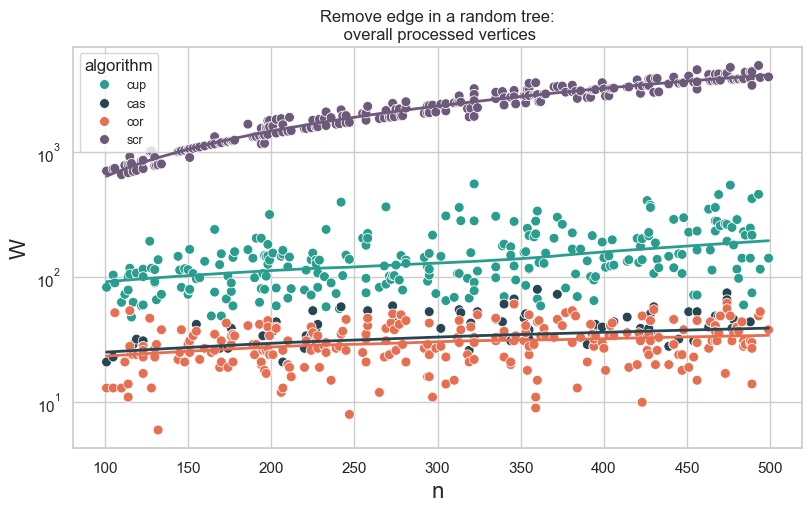

In [48]:
# 1. Trees - W - overall processed vertices in the update process

df_long = df_categorical(results_trees, "W", "W_scr")

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    sharey=True,
    figsize=(8, 5),
    constrained_layout=True
)

sns.scatterplot(data=df_long, 
                x="n", 
                y="W", 
                hue="algorithm", 
                palette=palette, 
                ax=ax,
                s=50)

scr_df = df_long[df_long["algorithm"] == "scr"]

for alg, color in palette.items():
    subset = df_long[df_long["algorithm"] == alg]
    
    sns.regplot(
        data=subset,
        x="n",
        y="W",
        scatter=False,
        lowess=True,
        ax=ax,
        line_kws={"lw": 2, "color": color}
    )

ax.set_title(f"Remove edge in a random tree:\n overall processed vertices")
ax.set_xlabel("n", fontsize=16)
ax.set_ylabel("W", fontsize=16)

plt.yscale('log')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="algorithm", fontsize=9)
plt.savefig(plots_path / "trees" / "W.png", dpi=300)
plt.show()



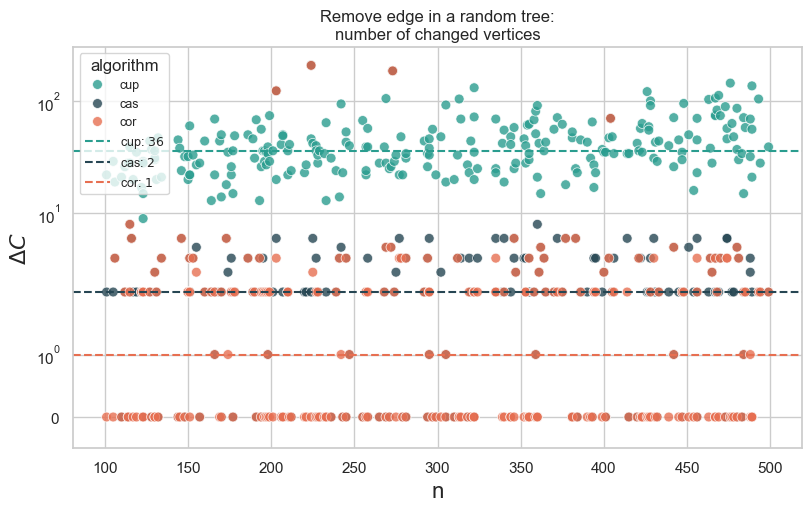

In [52]:
df_long = df_categorical(results_trees, "v_changed").copy()

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# scatter
sns.scatterplot(
    data=df_long,
    x="n",
    y="v_changed",
    hue="algorithm",
    palette=palette,
    ax=ax,
    s=50,
    alpha=0.8
)

# fit constant per algorithm
for alg in algorithms:
    df_alg = df_long[df_long["algorithm"] == alg]

    c = np.median(df_alg["v_changed"])

    ax.axhline(
        y=c,
        linestyle="--",
        color=palette[alg],
        linewidth=1.5,
        label=rf"{alg}: ${c:.2g}$"
    )

ax.set_title("Remove edge in a random tree:\nnumber of changed vertices")
ax.set_xlabel("n", fontsize=16)
ax.set_ylabel(r"$\Delta C$", fontsize=16)

ax.set_ylim(-0.5, 300)
ax.set_xscale("linear")
ax.set_yscale("symlog")

ax.legend(title="algorithm", fontsize=9, loc="upper left")

plt.show()


cup: slope=3.074e-02, range contribution ≈ 12.234
cas: slope=2.076e-03, range contribution ≈ 0.826
cor: slope=2.115e-03, range contribution ≈ 0.842


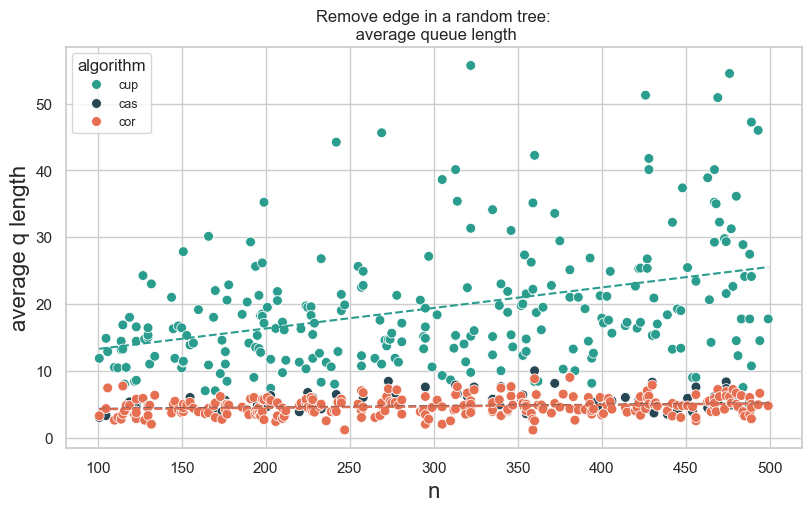

In [64]:
# average q len (real)

df_long = df_categorical(results_trees, "q_len_average")


fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    sharey=True,
    figsize=(8, 5),
    constrained_layout=True
)

sns.scatterplot(data=df_long, 
                x="n", 
                y="q_len_average", 
                hue="algorithm", 
                palette=palette, 
                ax=ax,
                s=50)

n_vals = np.linspace(df_long["n"].min(), df_long["n"].max(), 200)


for alg in algorithms:
    sub = df_long[df_long["algorithm"] == alg]

    x = sub["n"].values
    y = sub["q_len_average"].values

    # linear fit
    a, b = np.polyfit(x, y, 1)
    y_fit = a * n_vals + b
    print(f"{alg}: slope={a:.3e}, range contribution ≈ {a*(x.max()-x.min()):.3f}")
    ax.plot(
        n_vals,
        y_fit,
        color=palette[alg],
        linewidth=1.5,
        linestyle="--"
    )

ax.set_title(f"Remove edge in a random tree:\n average queue length")
ax.set_xlabel("n", fontsize=16)
ax.set_ylabel("average q length", fontsize=16)
plt.yscale('linear')


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="algorithm", fontsize=9)
plt.savefig(plots_path / "trees" / "average_q_len_average.png", dpi=300)
plt.show()

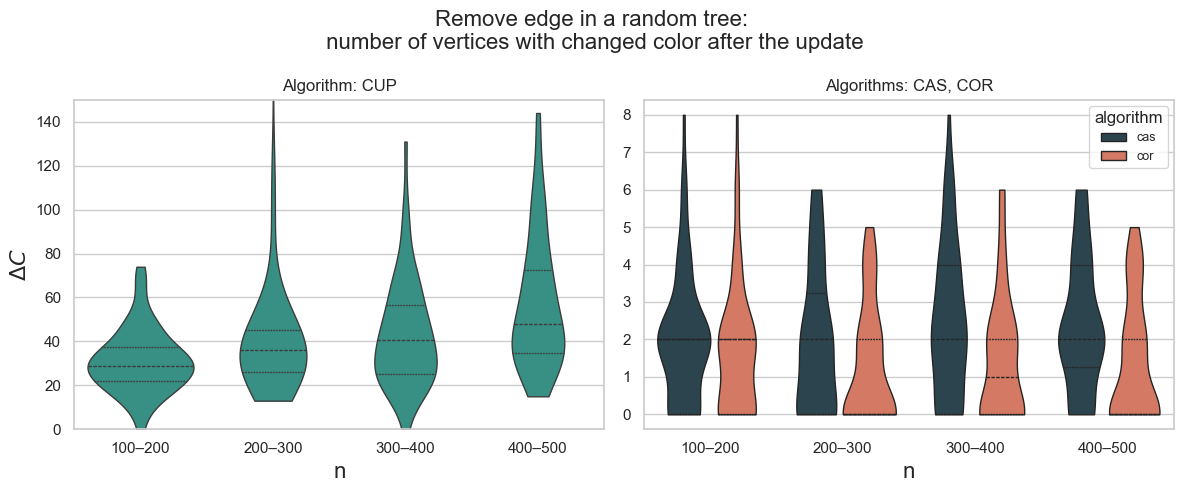

In [ ]:
# Box/violin - delta c

df = df_categorical(results_trees, "v_changed")

# Bin n
bins = [100, 200, 300, 400, 500]
labels = ["100–200", "200–300", "300–400", "400–500"]
df["n_bin"] = pd.cut(df["n"], bins=bins, labels=labels, include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# (a) CUP only
df_cup = df[df["algorithm"] == "cup"]
sns.violinplot(
    data=df_cup, 
    x="n_bin", 
    y="v_changed",
    hue="algorithm",
    hue_order=["cup"],
    palette={"cup": palette["cup"]},
    cut=0, 
    inner="quartile", 
    linewidth=1, 
    ax=axes[0]
)
axes[0].set_title("Algorithm: CUP")
axes[0].set_xlabel("n", fontsize=16)
axes[0].set_ylabel(r"$\Delta C$", fontsize=16)
axes[0].set_ylim(0, 150)
axes[0].legend_.remove()

# (b) CAS + COR
df_pruned = df[df["algorithm"].isin(["cas","cor"])]

low = df_pruned["v_changed"].quantile(0.01)
high = df_pruned["v_changed"].quantile(0.98)

df_filtered = df_pruned[
    (df_pruned["v_changed"] >= low) &
    (df_pruned["v_changed"] <= high)
]

sns.violinplot(
    data=df_filtered, 
    x="n_bin", 
    y="v_changed", 
    hue="algorithm",
    hue_order=["cas", "cor"],
    palette={"cas": palette["cas"], "cor": palette["cor"]},
    cut=0, 
    inner="quartile", 
    linewidth=1, 
    dodge=True, 
    ax=axes[1]
)
axes[1].set_title("Algorithms: CAS, COR")
axes[1].set_xlabel("n", fontsize=16)
axes[1].set_ylabel("")  # already on left
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title="algorithm", fontsize=9, loc="upper right")

fig.suptitle(f"Remove edge in a random tree:\n number of vertices with changed color after the update", fontsize=16)
plt.tight_layout()
plt.savefig(plots_path / "trees" / "delta_C_violin.png", dpi=300)
plt.show()

In [ ]:
# Summary statistics for delta c and delta T

order = ["cup", "cas", "cor"]
df = df_categorical(results_trees, "v_changed")
df = df.copy()
df["algorithm"] = pd.Categorical(df["algorithm"], categories=order, ordered=True)

# Summary statistics for c_delta, plus p(c_delta > 0)
desc_c = (df.groupby("algorithm", observed=False)["v_changed"]
            .describe(percentiles=[0.25, 0.5, 0.75])
            .rename(columns={"50%": "median"})
            .drop(columns=["count"]))

p_pos_c = (df.groupby("algorithm", observed=False)["v_changed"]
            .apply(lambda s: (s > 0).mean())
            .rename("p(c_delta>0)"))

tab_c = desc_c.join(p_pos_c).loc[order]
print("c_delta description:")
print(tab_c)

# Summary statistics for T_delta, plus p(T_delta != 0)
df = df_categorical(results_trees, "T_delta")
desc_T = (df.groupby("algorithm", observed=False)["T_delta"]
            .describe(percentiles=[0.25, 0.5, 0.75])
            .rename(columns={"50%": "median"})
            .drop(columns=["count"]))

p_nonzero_T = (df.groupby("algorithm", observed=False)["T_delta"]
                .apply(lambda s: (s != 0).mean())
                .rename("p(T_delta!=0)"))

tab_T = desc_T.join(p_nonzero_T).loc[order]
print("T_delta description:")
print(tab_T)


tab_c.to_latex(plots_path / "trees" / "table_c_delta_describe.tex", float_format="%.4g")
tab_T.to_latex(plots_path / "trees" / "table_T_delta_describe.tex", float_format="%.4g")

c_delta description:
             mean        std  min    25%  median    75%    max  p(c_delta>0)
algorithm                                                                   
cup        43.848  28.141369  0.0  26.25    36.0  50.75  208.0         0.992
cas         4.464  19.443893  0.0   0.00     2.0   4.00  207.0         0.716
cor         3.744  19.511465  0.0   0.00     1.0   2.00  207.0         0.528
T_delta description:
           mean       std  min  25%  median  75%  max  p(T_delta!=0)
algorithm                                                           
cup        0.00  0.000000  0.0  0.0     0.0  0.0  0.0          0.000
cas        0.66  1.267607  0.0  0.0     0.0  1.0  6.0          0.260
cor        1.18  1.519485  0.0  0.0     0.0  2.0  6.0          0.452


In [ ]:
# Summary statistics for T_scr
order = ["cup", "cas", "cor"]
df = df_categorical(results_trees, "T_scr")

df["algorithm"] = pd.Categorical(df["algorithm"], categories=order, ordered=True)

tab_T = (df[df["algorithm"] == "cup"]["T_scr"]
            .describe(percentiles=[0.25, 0.5, 0.75])
            .rename({"50%": "median"})
            .drop("count")
            .to_frame(name="T_scr")
            .T)


print(tab_T)

# LaTeX export
tab_T.to_latex(plots_path / "trees" / "table_T_scr_describe.tex", float_format="%.4g")

        mean       std  min  25%  median  75%   max
T_scr  7.728  0.899585  6.0  7.0     8.0  8.0  10.0


### Random graphs

In [93]:
results_rg = {
    "p_05": {
        "a_1": {up_func: unpack_file("rg_p_05_a_1", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_5": {up_func: unpack_file("rg_p_05_a_5", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_10": {up_func: unpack_file("rg_p_05_a_10", up_func) for up_func in ["cup", "cas", "cor"]},
    },
    "p_1": {
        "a_1": {up_func: unpack_file("rg_p_1_a_1", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_5": {up_func: unpack_file("rg_p_1_a_5", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_10": {up_func: unpack_file("rg_p_1_a_10", up_func) for up_func in ["cup", "cas", "cor"]},
    },
    "p_5": {
        "a_1": {up_func: unpack_file("rg_p_5_a_1", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_5": {up_func: unpack_file("rg_p_5_a_5", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_10": {up_func: unpack_file("rg_p_5_a_10", up_func) for up_func in ["cup", "cas", "cor"]},
    }
}

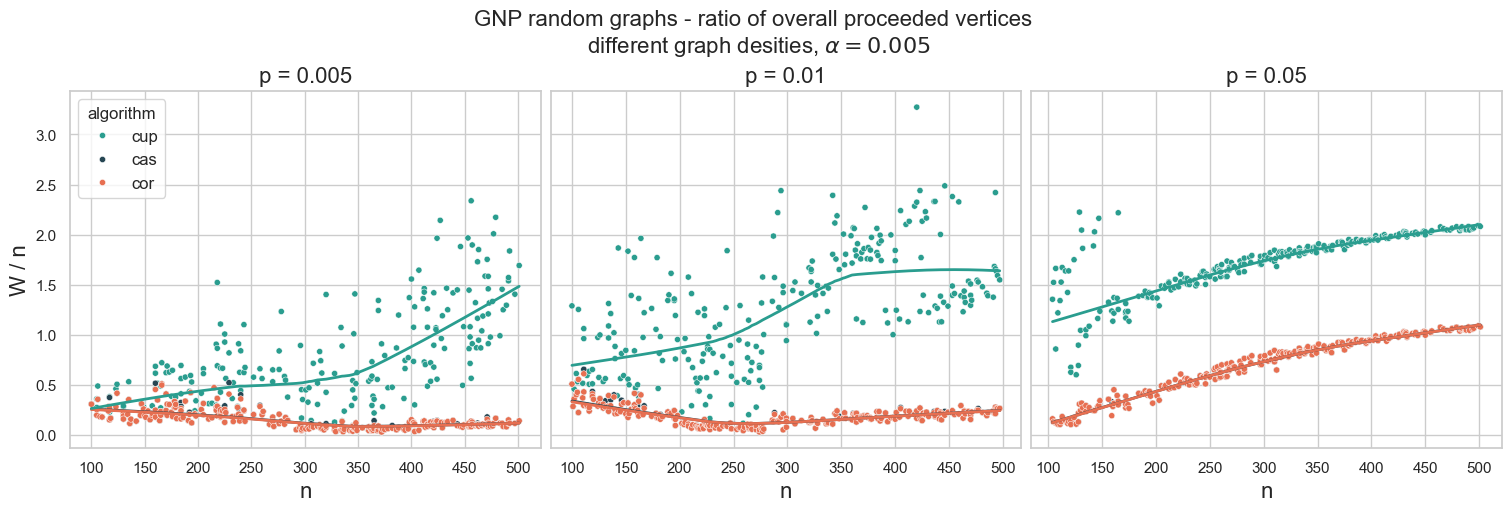

<Figure size 640x480 with 0 Axes>

In [120]:
# Number of proceeded vertices - 
# different graph densities p vs perturbation parameter alpha = 0.005
results = [results_rg[p]["a_5"] for p in p_list]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)

for k in range(3):
    ax = axes[k]
    p = [0.005, 0.01, 0.05][k]

    df_long = df_categorical(results[k], "W").copy()
    df_long["W_norm"] = df_long["W"] / df_long["n"]

    # scatter for cup/cas/cor
    sns.scatterplot(
        data=df_long,
        x="n",
        y="W_norm",
        hue="algorithm",
        palette=palette,
        ax=ax,
        s=20
    )

    # fit lowess per algorithm
    for alg, color in palette.items():
        subset = df_long[df_long["algorithm"] == alg]
        
        sns.regplot(
            data=subset,
            x="n",
            y="W_norm",
            scatter=False,
            lowess=True,
            ax=ax,
            line_kws={"lw": 2, "color": color}
        )
    ax.set_title(f"p = {p}", fontsize=16)
    ax.set_xlabel("n", fontsize=16)
    ax.set_ylabel("W / n", fontsize=16)
    ax.legend_.remove()    

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="algorithm", fontsize=12, loc="upper left")
    
fig.suptitle(f"GNP random graphs - ratio of overall proceeded vertices \n different graph desities, " + r"$\alpha = 0.005$", fontsize=16)
plt.show()
plt.savefig(plots_path / "random_graphs" / "W_norm_vs_p.png", dpi=300)


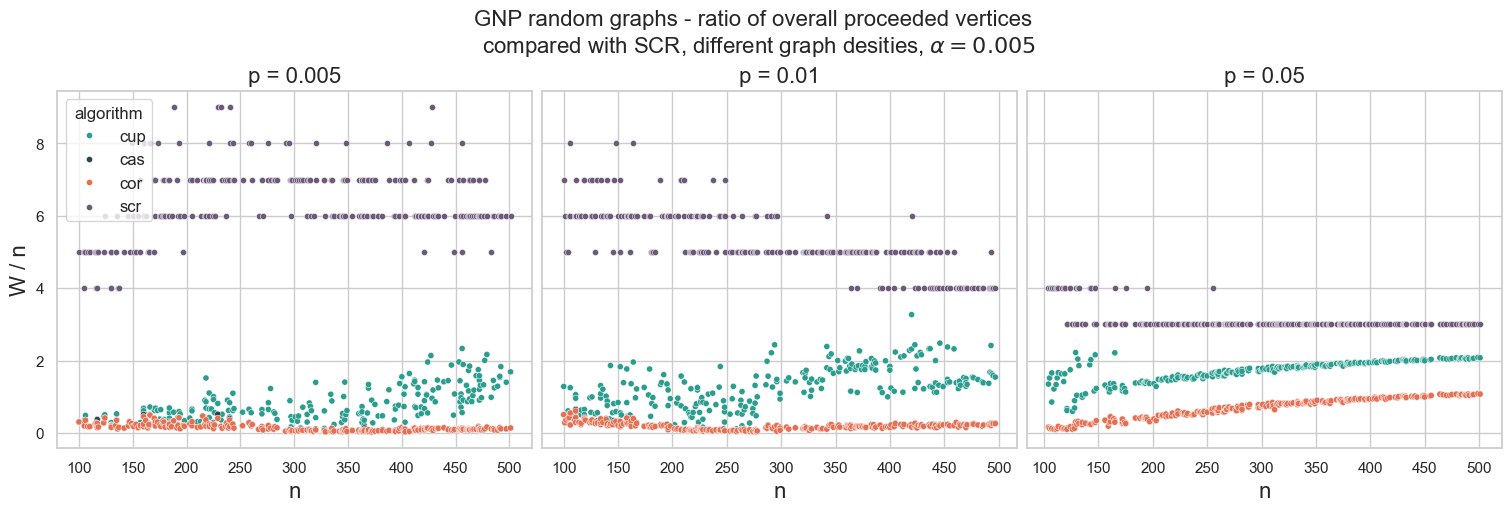

<Figure size 640x480 with 0 Axes>

In [121]:
# Number of proceeded vertices - 
# different graph densities p vs perturbation parameter alpha = 0.005
# Compare with standard color refinement

results = [results_rg[p]["a_5"] for p in p_list]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)

for k in range(3):
    ax = axes[k]
    p = [0.005, 0.01, 0.05][k]

    # df_long contains cup, cas, cor from W, and scr from T_scr
    df_long = df_categorical(results[k], "W", "T_scr").copy()

    # separate actual algorithms from scr baseline
    df_alg = df_long[df_long["algorithm"] != "scr"].copy()
    df_scr = df_long[df_long["algorithm"] == "scr"].copy()


    df_alg["W_norm"] = df_alg["W"] / df_alg["n"]
    df_scr["W_norm"] = df_scr["W"]   # here W already stores T_scr

    # scatter for cup/cas/cor
    sns.scatterplot(
        data=df_alg,
        x="n",
        y="W_norm",
        hue="algorithm",
        palette=palette,
        ax=ax,
        s=20
    )

    # scatter for scr 
    sns.scatterplot(
        data=df_scr,
        x="n",
        y="W_norm",
        color=palette["scr"],
        ax=ax,
        s=20,
        label="scr"
    )

    ax.set_title(f"p = {p}", fontsize=16)
    ax.set_xlabel("n", fontsize=16)
    ax.set_ylabel("W / n", fontsize=16)

    if k > 0:
        ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="algorithm", fontsize=12, loc="upper left")

fig.suptitle(f"GNP random graphs - ratio of overall proceeded vertices \n compared with SCR, different graph desities, " + r"$\alpha = 0.005$", fontsize=16)
plt.show()
plt.savefig(plots_path / "random_graphs" / "W_norm_vs_p_scr.png", dpi=300)

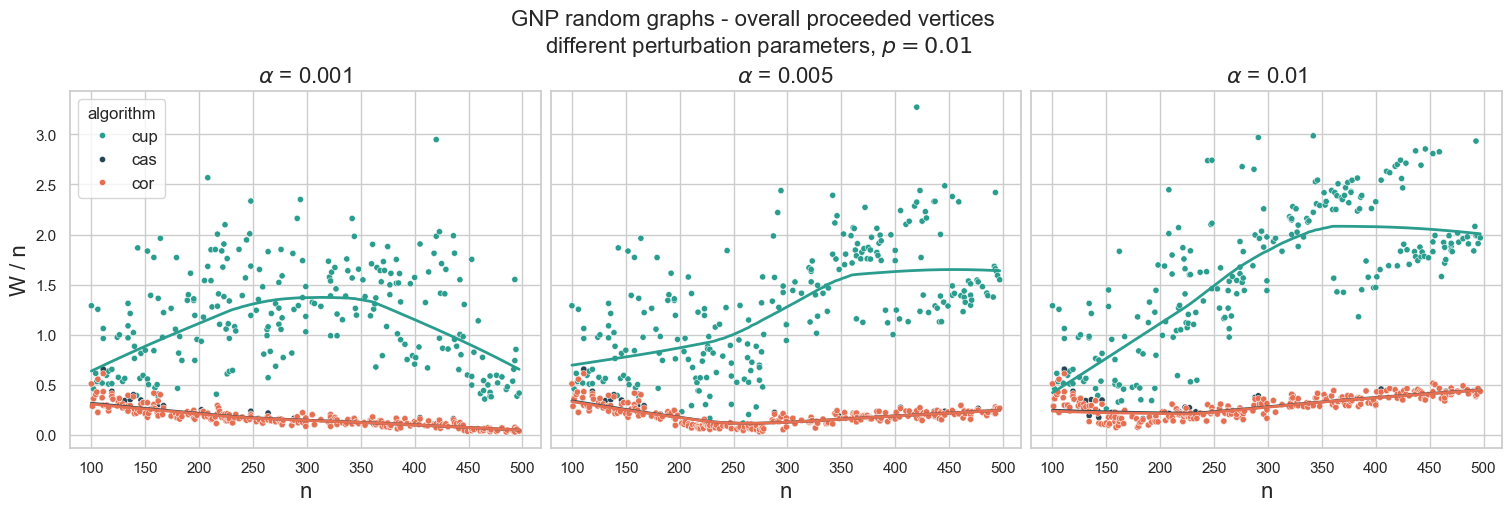

In [110]:
# Number of proceeded vertices -
# gnp random graphs with p=0.01, different perturbation parameter alpha
results = [results_rg["p_1"][a] for a in a_list]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)
for k in range(3):
    ax = axes[k]
    a = [0.001, 0.005, 0.01][k]
    df_long = df_categorical(results[k], "W")
    df_long["W_norm"] = df_long["W"] /df_long["n"]
    sns.scatterplot(data=df_long, 
                    x="n", 
                    y="W_norm", 
                    hue="algorithm", 
                    palette=palette, 
                    ax=ax,
                    s=20)
    
    # fit lowess per algorithm
    for alg, color in palette.items():
        subset = df_long[df_long["algorithm"] == alg]
        
        sns.regplot(
            data=subset,
            x="n",
            y="W_norm",
            scatter=False,
            lowess=True,
            ax=ax,
            line_kws={"lw": 2, "color": color}
        )

    ax.set_title(fr"$\alpha$ = {a}", fontsize=16)
    ax.set_xlabel("n", fontsize=16)
    ax.set_ylabel("W / n", fontsize=16)

    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="algorithm", fontsize=12, loc="upper left")

fig.suptitle(f"GNP random graphs - overall proceeded vertices \n different perturbation parameters, " + r"$p = 0.01$", fontsize=16)
plt.savefig(plots_path / "random_graphs" / "W_norm_vs_alpha.png", dpi=300)
plt.show()

### Queue length

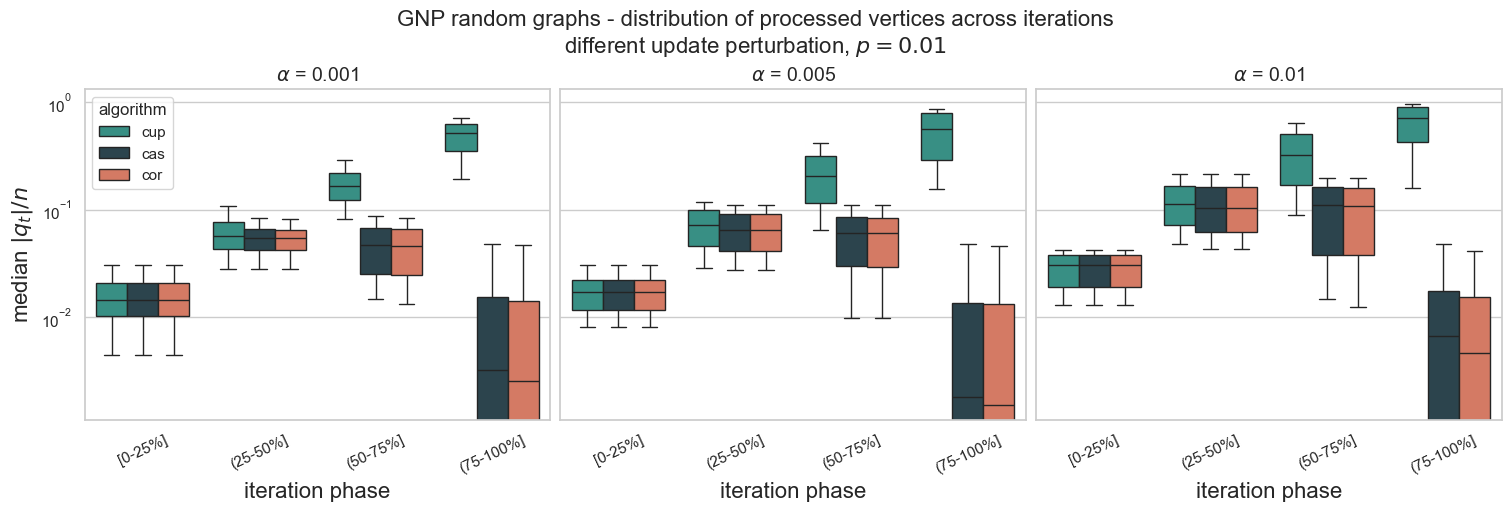

In [125]:
results  = [results_rg["p_1"][a] for a in a_list]

# ---------- helpers ----------
def explode_q_lens(df_long):
    """
    Take the list of queue lengths from the specified column and put it into separate rows.
    """
    d = df_long.copy()
    d = d.explode("q_lens", ignore_index=True)
    d = d.rename(columns={"q_lens": "q_len"})
    d["q_len"] = pd.to_numeric(d["q_len"], errors="coerce")
    d = d.dropna(subset=["q_len"])

    run_cols = [c for c in d.columns if c not in ["q_len"]]
    d["iter"] = d.groupby(run_cols, observed=False).cumcount() + 1
    return d

def add_phase_bins(df_it):
    """
    Split each run into relative iteration phases.

    Computes r = iter / T per run (T = total iterations) and assigns each
    iteration to one of n_bins intervals over (0, 1].
    Adds a categorical column bin_col with the phase labels.
    """
    run_cols = [c for c in df_it.columns if c not in ["q_len", "iter", "q_frac", "phase"]]

    T = df_it.groupby(run_cols)["iter"].transform("max")
    rel_iter = df_it["iter"] / T

    labels = ["[0-25%]", "(25-50%]", "(50-75%]", "(75-100%]"]
    df_it["phase"] = pd.cut(
        rel_iter,
        bins=[0, 0.25, 0.5, 0.75, 1.0],
        labels=labels,
        right=True
    )
    return df_it, run_cols, labels

# ---------- build + plot ----------
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(a_list),
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)
for k, a in enumerate(a_list):
    ax = axes[k]

    df_long = df_categorical(results[k], "q_lens")
    df_it = explode_q_lens(df_long)

    df_it["q_frac"] = df_it["q_len"] / df_it["n"]
    df_it, run_cols, phase_order = add_phase_bins(df_it)

    df_phase = (
        df_it.groupby(run_cols + ["phase"], as_index=False, observed=False)["q_frac"]
        .median()
        .rename(columns={"q_frac": "q_frac_median"})
    )

    sns.boxplot(
        data=df_phase,
        x="phase",
        y="q_frac_median",
        hue="algorithm",
        hue_order=["cup", "cas", "cor"],
        order=phase_order,
        showfliers=False,
        whis=(10, 90),
        palette=palette,
        ax=ax
    )

    ax.set_title(rf"$\alpha$ = {[0.001, 0.005, 0.01][k]}", fontsize=14)
    ax.set_xlabel("iteration phase", fontsize=16)
    ax.set_ylabel(r"median $|q_t|/n$", fontsize=16)
    ax.tick_params(axis="x", rotation=25)
    ax.set_yscale("log")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes[1:]:
    ax.legend_.remove()

axes[0].legend(handles, labels, title="algorithm", loc="upper left")

fig.suptitle(
    "GNP random graphs - distribution of processed vertices across iterations\n"
    + r"different update perturbation, $p = 0.01$",
    fontsize=16
)

plt.savefig(plots_path / "random_graphs" / "q_distribution_log.png", dpi=300)
plt.show()

### Number of changed vertices, delta C

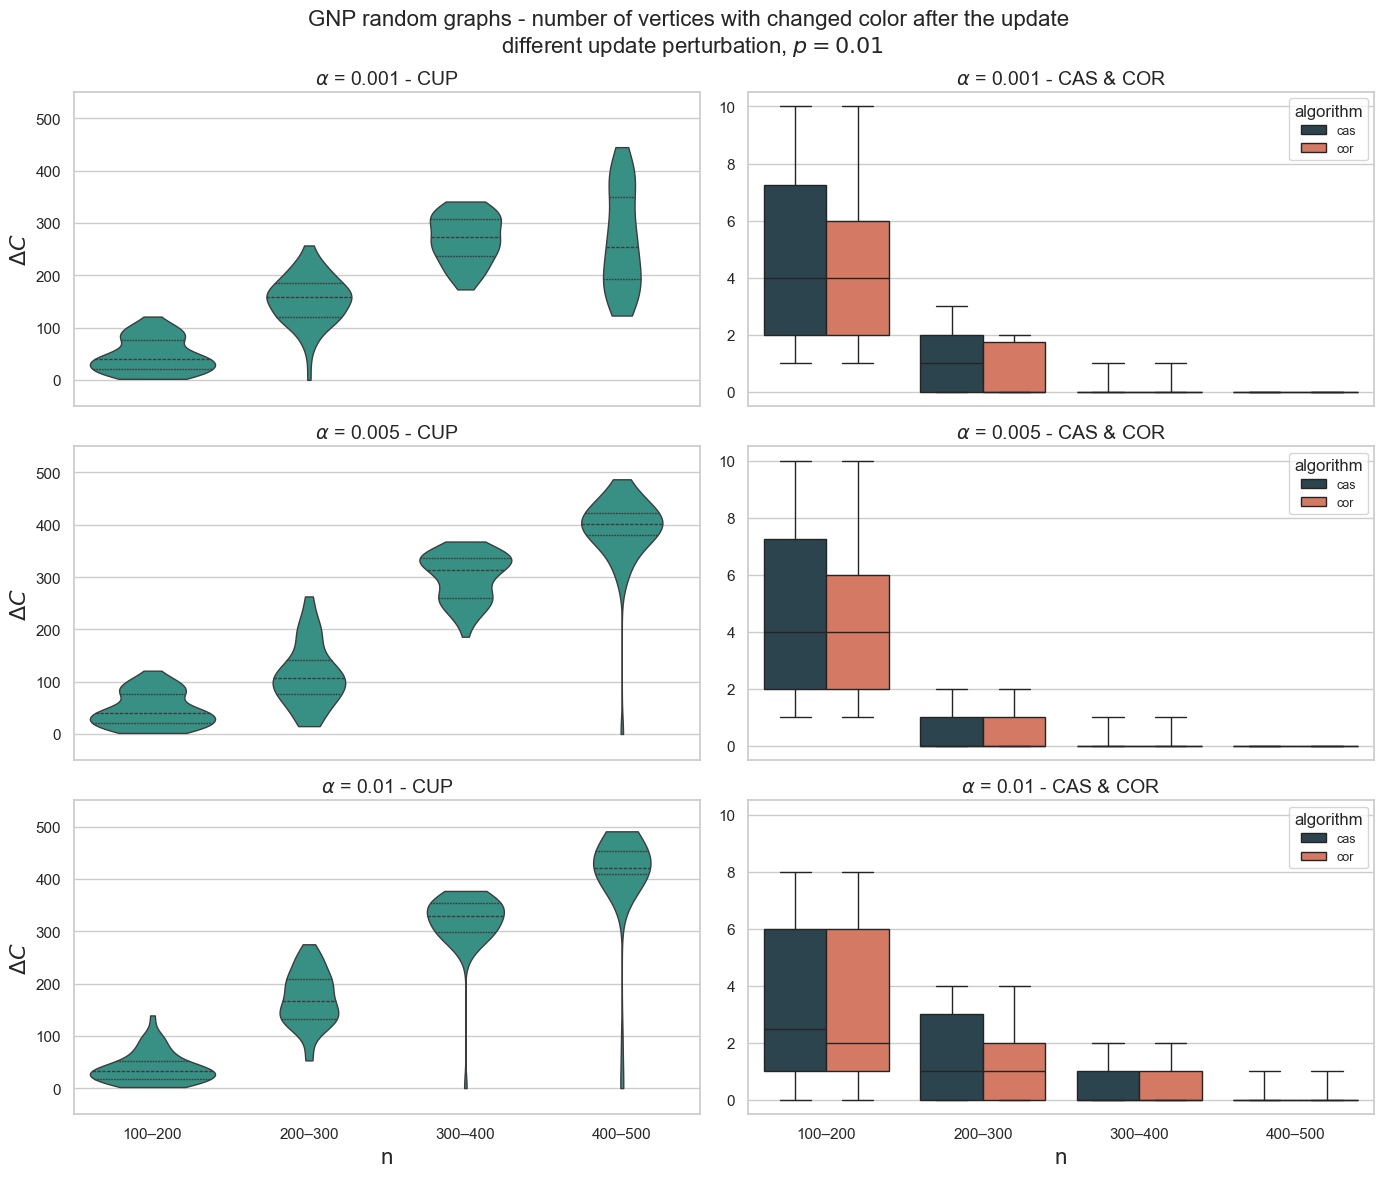

In [128]:
# Delta C - different perturbation parameter alpha, p=0.01

fig, axes = plt.subplots(
    nrows=len(a_list),
    ncols=2,
    figsize=(14, 12),
    sharex=True
)

for i, a in enumerate([0.001, 0.005, 0.01]):

    df = df_categorical(results[i], "v_changed") 
    bins = [100, 200, 300, 400, 500] 
    labels = ["100–200", "200–300", "300–400", "400–500"] 
    df["n_bin"] = pd.cut(df["n"], bins=bins, labels=labels, include_lowest=True)
    
    # ---- CUP (left column) ----
    df_cup = df[df["algorithm"] == "cup"]

    sns.violinplot(
        data=df_cup,
        x="n_bin",
        y="v_changed",
        hue="algorithm",
        hue_order=["cup"],
        palette={"cup": palette["cup"]},
        cut=0,
        inner="quartile",
        linewidth=1,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(rf"$\alpha$ = {a} - CUP", fontsize=14)
    axes[i, 0].set_ylabel(r"$\Delta C$", fontsize=16)
    axes[i, 0].legend_.remove()
    axes[i, 0].set_ylim(-50,550)


    # ---- CAS + COR (right column) ----
    df_pruned = df[df["algorithm"].isin(["cas", "cor"])]

    sns.boxplot(
        data=df_pruned,
        x="n_bin",
        y="v_changed",
        hue="algorithm",
        hue_order=["cas", "cor"],
        palette={"cas": palette["cas"], "cor": palette["cor"]},
        linewidth=1,
        dodge=True,
        ax=axes[i, 1],
        whis=(10, 90),
        showfliers=False,
    )

    axes[i, 1].set_title(rf"$\alpha$ = {a} - CAS & COR", fontsize=14)
    axes[i, 1].set_ylabel("")
    axes[i, 1].legend(title="algorithm", fontsize=9)
    axes[i, 1].set_ylim(-0.5, 10.5)

axes[2, 0].set_xlabel("n", fontsize=16)
axes[2, 1].set_xlabel("n", fontsize=16)
fig.suptitle(f"GNP random graphs - number of vertices with changed color after the update \n"
            f"different update perturbation, " + r"$p = 0.01$", fontsize=16)
plt.savefig(plots_path / "random_graphs" / "C_delta_vs_alpha.png", dpi=300)

plt.tight_layout()
plt.show()


In [130]:
# Summary table: c_delta, t_delta

order = ["cup", "cas", "cor"]
results  = [results_rg["p_1"][a] for a in a_list]
for i in [0,1,2]:
    print(f"\n {a_list[i]}")
    dfC = df_categorical(results[i], "v_changed")
    dfT = df_categorical(results[i], "T_delta")

    df = dfC.merge(dfT, on=["graph_id","n","algorithm"], how="inner", validate="one_to_one")

    df["c_delta"] = df["v_changed"]
    df["algorithm"] = pd.Categorical(df["algorithm"], categories=order, ordered=True)

    desc_c = (df.groupby("algorithm", observed=False)["c_delta"]
                .describe(percentiles=[0.25, 0.5, 0.75])
                .rename(columns={"50%": "median"})
                .drop(columns=["count"]))

    p_pos_c = (df.groupby("algorithm", observed=False)["c_delta"]
                .apply(lambda s: (s > 0).mean())
                .rename("p(c_delta>0)"))

    tab_c = desc_c.join(p_pos_c).loc[order]
    print(tab_c)

    # Same idea for T_delta, plus p(T_delta != 0)
    desc_T = (df.groupby("algorithm", observed=False)["T_delta"]
                .describe(percentiles=[0.25, 0.5, 0.75])
                .rename(columns={"50%": "median"})
                .drop(columns=["count"]))

    p_nonzero_T = (df.groupby("algorithm", observed=False)["T_delta"]
                    .apply(lambda s: (s != 0).mean())
                    .rename("p(T_delta!=0)"))

    tab_T = desc_T.join(p_nonzero_T).loc[order]
    print(tab_T)

    # Optional: LaTeX export
    tab_c.to_latex(plots_path / "random_graphs" / f"table_c_delta_{a_list[i]}.tex", float_format="%.4g")
    tab_T.to_latex(plots_path / "random_graphs" / f"table_T_delta_{a_list[i]}.tex", float_format="%.4g")


 a_1
              mean         std  min   25%  median    75%    max  p(c_delta>0)
algorithm                                                                    
cup        175.884  108.482961  0.0  88.0   169.5  256.5  445.0         0.996
cas          3.032   10.824957  0.0   0.0     0.0    2.0  121.0         0.456
cor          2.892   10.810541  0.0   0.0     0.0    2.0  121.0         0.436
            mean       std  min  25%  median  75%  max  p(T_delta!=0)
algorithm                                                            
cup        0.000  0.000000  0.0  0.0     0.0  0.0  0.0          0.000
cas        0.804  0.858213  0.0  0.0     1.0  1.0  3.0          0.536
cor        0.844  0.875632  0.0  0.0     1.0  2.0  4.0          0.556

 a_5
              mean         std  min   25%  median    75%    max  p(c_delta>0)
algorithm                                                                    
cup        199.184  147.171369  0.0  67.0   161.5  336.0  487.0         0.996
cas          2

In [133]:
order = ["cup", "cas", "cor"]
p_list  = ["p_05", "p_1", "p_5"]
results = [results_rg[p]["a_1"]["cor"] for p in p_list]

# build one combined table
rows = {}

for p, df in zip(p_list, results):
    desc = df["T_scr"].describe(percentiles=[0.25, 0.5, 0.75])
    rows[p] = desc

table = pd.DataFrame(rows).T 
table.drop(columns=["count"], inplace=True)
print(table)


table.to_latex(plots_path / "random_graphs" / "table_T_scr_describe.tex", float_format="%.4g")

       mean       std  min  25%  50%  75%  max
p_05  6.408  0.945044  4.0  6.0  6.0  7.0  9.0
p_1   5.296  0.887431  4.0  5.0  5.0  6.0  8.0
p_5   3.096  0.295182  3.0  3.0  3.0  3.0  4.0
